Install Libraries & Import Packages

In [ ]:
# === A: Install & Import Core Libraries ===

# Install essential libraries (latest versions)
!pip install -q tensorflow keras opencv-python scikit-learn matplotlib seaborn pandas tqdm

# Optional: extra tools
!pip install -q albumentations  # for augmentations
!pip install -q split-folders   # to split dataset
!pip install -q streamlit       # GUI

# --- Imports ---
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix
from tqdm import tqdm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 67.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 72.6 MB/s eta 0:00:00


Upload kaggle.json and configure Kaggle API

In [ ]:
# === Cell 2: Kaggle Authentication Setup ===
import os
import shutil  # <-- required for copyfile
from google.colab import files

print("If you already uploaded kaggle.json to the Files panel, skip uploading again.")
uploaded = files.upload()  # choose kaggle.json from your computer; cancel if already present

# Create directory and copy kaggle.json
os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
if 'kaggle.json' in uploaded or os.path.exists('kaggle.json'):
    src = 'kaggle.json' if os.path.exists('kaggle.json') else list(uploaded.keys())[0]
    shutil.copyfile(src, os.path.expanduser("~/.kaggle/kaggle.json"))
    os.chmod(os.path.expanduser("~/.kaggle/kaggle.json"), 0o600)
    print(" kaggle.json installed to ~/.kaggle")
else:
    print(" No kaggle.json detected. Please upload it if you want to download from Kaggle.")


If you already uploaded kaggle.json to the Files panel, skip uploading again.


Saving kaggle.json to kaggle.json
 kaggle.json installed to ~/.kaggle


Download HAM10000 from Kaggle and unzip

In [ ]:
# === Cell 3: Download and Unzip Skin Cancer Dataset from Kaggle ===
import os
import zipfile
import glob  # needed for file searching
import shutil

# Define dataset info
DATASET_SLUG = "kmader/skin-cancer-mnist-ham10000"
RAW_DIR = "/content/skin_cancer_raw"

# Create directory to store raw files
os.makedirs(RAW_DIR, exist_ok=True)

# Download dataset using Kaggle CLI
!kaggle datasets download -d {DATASET_SLUG} -p {RAW_DIR}

# Unzip all .zip files found in RAW_DIR
for z in glob.glob(os.path.join(RAW_DIR, "*.zip")):
    print(" Unzipping:", z)
    with zipfile.ZipFile(z, 'r') as zip_ref:
        zip_ref.extractall(RAW_DIR)

print(" Dataset downloaded and extracted successfully to:", RAW_DIR)


Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
License(s): CC-BY-NC-SA-4.0
100% 5.19G/5.20G [02:22<00:00, 85.6MB/s]
100% 5.20G/5.20G [02:22<00:00, 39.2MB/s]
 Unzipping: /content/skin_cancer_raw/skin-cancer-mnist-ham10000.zip
 Dataset downloaded and extracted successfully to: /content/skin_cancer_raw


Inspect dataset files (quick check)

In [ ]:
# Cell 4: Inspect the RAW_DIR contents to see what was downloaded/unzipped
RAW_DIR = "/content/skin_cancer_raw"
print("Top-level files and folders in", RAW_DIR)
for p in sorted(os.listdir(RAW_DIR))[:50]:
    print(" ",p)
print("\nLook for HAM10000_metadata.csv and image files (jpg).")


Top-level files and folders in /content/skin_cancer_raw
  HAM10000_images_part_1
  HAM10000_images_part_2
  HAM10000_metadata.csv
  ham10000_images_part_1
  ham10000_images_part_2
  hmnist_28_28_L.csv
  hmnist_28_28_RGB.csv
  hmnist_8_8_L.csv
  hmnist_8_8_RGB.csv
  skin-cancer-mnist-ham10000.zip

Look for HAM10000_metadata.csv and image files (jpg).


Prepare organized dataset folder (map labels to 4 classes)

In [ ]:
# === Cell 5: Create dataset folders and copy images into 4 class folders ===
import os
import glob
import shutil
import pandas as pd  #  <-- this was missing
from tqdm import tqdm  # optional for progress bars (nice touch)

DATASET_PATH = "/content/skin_cancer_dataset"   # final organized dataset root
os.makedirs(DATASET_PATH, exist_ok=True)

# create class folders for Keras flow_from_directory
classes = ['Melanoma','BCC','SCC','Benign']
for c in classes:
    os.makedirs(os.path.join(DATASET_PATH, c), exist_ok=True)

# Attempt to find metadata CSV in RAW_DIR
meta_candidates = glob.glob(os.path.join(RAW_DIR, "*metadata*.csv")) + glob.glob(os.path.join(RAW_DIR, "*.csv"))
meta_path = meta_candidates[0] if meta_candidates else None
print(" Metadata CSV found:", meta_path)

# mapping dx -> 4-class
label_map = {
    'mel':'Melanoma','melanoma':'Melanoma',
    'bcc':'BCC','scc':'SCC',
    'nv':'Benign','akiec':'Benign','bkl':'Benign','df':'Benign','vasc':'Benign'
}

if meta_path and os.path.exists(meta_path):
    df = pd.read_csv(meta_path)
    print(" Metadata rows:", len(df))

    # Try to locate image files: sometimes located directly in RAW_DIR or subfolders
    image_search_dirs = [RAW_DIR] + [d for d in glob.glob(os.path.join(RAW_DIR, "*")) if os.path.isdir(d)]

    copied, missing = 0, 0
    for _, row in tqdm(df.iterrows(), total=len(df), desc="Copying images"):
        img_id = str(row.get('image_id') or row.get('image_id:') or "")
        dx = str(row.get('dx','')).lower()
        label = label_map.get(dx, 'Benign')
        found = None
        for d in image_search_dirs:
            for ext in (".jpg",".jpeg",".png"):
                p = os.path.join(d, img_id + ext)
                if os.path.exists(p):
                    found = p; break
            if found: break
        if found:
            dst = os.path.join(DATASET_PATH, label, os.path.basename(found))
            if not os.path.exists(dst):
                shutil.copyfile(found, dst)
            copied += 1
        else:
            missing += 1

    print(f" Copied {copied} images,  Missing {missing} (not found).")
else:
    print(" No metadata CSV found. If you have only images, please organize manually into class folders.")


 Metadata CSV found: /content/skin_cancer_raw/HAM10000_metadata.csv
 Metadata rows: 10015


Copying images: 100%|██████████| 10015/10015 [00:39<00:00, 254.19it/s]

 Copied 10015 images,  Missing 0 (not found).


Quick verify dataset folder structure & counts

In [ ]:
# Cell 6: Verify that class folders have images and show sample counts
print("Dataset path:", DATASET_PATH)
total = 0
for c in classes:
    files = glob.glob(os.path.join(DATASET_PATH, c, "*.*"))
    print(f" Class {c}: {len(files)} images. Examples: {files[:3]}")
    total += len(files)
print("Total images organized:", total)
if total == 0:
    raise RuntimeError("No images found in class folders. Fix dataset organization (see previous cells).")


Dataset path: /content/skin_cancer_dataset
 Class Melanoma: 1113 images. Examples: ['/content/skin_cancer_dataset/Melanoma/ISIC_0032269.jpg', '/content/skin_cancer_dataset/Melanoma/ISIC_0030623.jpg', '/content/skin_cancer_dataset/Melanoma/ISIC_0032690.jpg']
 Class BCC: 514 images. Examples: ['/content/skin_cancer_dataset/BCC/ISIC_0029755.jpg', '/content/skin_cancer_dataset/BCC/ISIC_0032991.jpg', '/content/skin_cancer_dataset/BCC/ISIC_0027819.jpg']
 Class SCC: 0 images. Examples: []
 Class Benign: 8388 images. Examples: ['/content/skin_cancer_dataset/Benign/ISIC_0025421.jpg', '/content/skin_cancer_dataset/Benign/ISIC_0024942.jpg', '/content/skin_cancer_dataset/Benign/ISIC_0026216.jpg']
Total images organized: 10015


Create Keras ImageDataGenerators (fixes the '0 images' problem)

In [ ]:
# Cell 7: Use ImageDataGenerator.flow_from_directory to create train & validation generators
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 224
BATCH_SIZE = 16

datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_gen = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_gen = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

print("Class indices mapping (label -> index):", train_gen.class_indices)


Found 8014 images belonging to 4 classes.
Found 2001 images belonging to 4 classes.
Class indices mapping (label -> index): {'BCC': 0, 'Benign': 1, 'Melanoma': 2, 'SCC': 3}



Build MobileNetV2 transfer-learning classifier (fast & accurate)

In [ ]:
# Cell 8: Build MobileNetV2-based classifier (Requirement 2 & 4)
import tensorflow as tf
from tensorflow.keras import layers, models

num_classes = len(train_gen.class_indices)

base = tf.keras.applications.MobileNetV2(input_shape=(IMG_SIZE,IMG_SIZE,3), include_top=False, weights='imagenet')
base.trainable = False  # freeze base for initial training

x = layers.GlobalAveragePooling2D()(base.output)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

clf_model = models.Model(inputs=base.input, outputs=outputs)
clf_model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
clf_model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Train classification model (with callbacks) — start small to test

In [ ]:
# Cell 9: Train classifier (adjust EPOCHS for full training; use 5-10 to test)
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping

EPOCHS = 8   # start small; increase later e.g. 20-50
MODEL_SAVE_PATH = os.path.join(DRIVE_MODELS_DIR if os.path.exists('/content/drive') else '/content', "mobilenet_best.h5")

callbacks = [
    ModelCheckpoint(MODEL_SAVE_PATH, monitor='val_accuracy', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
    EarlyStopping(monitor='val_loss', patience=7, verbose=1)
]

history = clf_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks
)

print("Training complete. Best model saved to:", MODEL_SAVE_PATH)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/8
501/501 ━━━━━━━━━━━━━━━━━━━━ 0s 710ms/step - accuracy: 0.8052 - loss: 0.5942
Epoch 1: val_accuracy improved from -inf to 0.84558, saving model to /content/mobilenet_best.h5


501/501 ━━━━━━━━━━━━━━━━━━━━ 454s 893ms/step - accuracy: 0.8053 - loss: 0.5940 - val_accuracy: 0.8456 - val_loss: 0.4165 - learning_rate: 1.0000e-04
Epoch 2/8
501/501 ━━━━━━━━━━━━━━━━━━━━ 0s 731ms/step - accuracy: 0.8338 - loss: 0.4415
Epoch 2: val_accuracy did not improve from 0.84558
501/501 ━━━━━━━━━━━━━━━━━━━━ 509s 1s/step - accuracy: 0.8338 - loss: 0.4415 - val_accuracy: 0.8446 - val_loss: 0.4157 - learning_rate: 1.0000e-04
Epoch 3/8
501/501 ━━━━━━━━━━━━━━━━━━━━ 0s 744ms/step - accuracy: 0.8535 - loss: 0.3816
Epoch 3: val_accuracy improved from 0.84558 to 0.85257, saving model to /content/mobilenet_best.h5


501/501 ━━━━━━━━━━━━━━━━━━━━ 462s 923ms/step - accuracy: 0.8535 - loss: 0.3816 - val_accuracy: 0.8526 - val_loss: 0.3788 - learning_rate: 1.0000e-04
Epoch 4/8
501/501 ━━━━━━━━━━━━━━━━━━━━ 0s 735ms/step - accuracy: 0.8579 - loss: 0.3714
Epoch 4: val_accuracy improved from 0.85257 to 0.85357, saving model to /content/mobilenet_best.h5


501/501 ━━━━━━━━━━━━━━━━━━━━ 511s 1s/step - accuracy: 0.8579 - loss: 0.3714 - val_accuracy: 0.8536 - val_loss: 0.3779 - learning_rate: 1.0000e-04
Epoch 5/8
501/501 ━━━━━━━━━━━━━━━━━━━━ 0s 751ms/step - accuracy: 0.8686 - loss: 0.3449
Epoch 5: val_accuracy did not improve from 0.85357
501/501 ━━━━━━━━━━━━━━━━━━━━ 465s 928ms/step - accuracy: 0.8686 - loss: 0.3449 - val_accuracy: 0.8536 - val_loss: 0.3754 - learning_rate: 1.0000e-04
Epoch 6/8
501/501 ━━━━━━━━━━━━━━━━━━━━ 0s 722ms/step - accuracy: 0.8728 - loss: 0.3280
Epoch 6: val_accuracy improved from 0.85357 to 0.85957, saving model to /content/mobilenet_best.h5


501/501 ━━━━━━━━━━━━━━━━━━━━ 462s 923ms/step - accuracy: 0.8728 - loss: 0.3280 - val_accuracy: 0.8596 - val_loss: 0.3651 - learning_rate: 1.0000e-04
Epoch 7/8
501/501 ━━━━━━━━━━━━━━━━━━━━ 0s 713ms/step - accuracy: 0.8790 - loss: 0.3091
Epoch 7: val_accuracy did not improve from 0.85957
501/501 ━━━━━━━━━━━━━━━━━━━━ 446s 889ms/step - accuracy: 0.8790 - loss: 0.3092 - val_accuracy: 0.8506 - val_loss: 0.3606 - learning_rate: 1.0000e-04
Epoch 8/8
501/501 ━━━━━━━━━━━━━━━━━━━━ 0s 739ms/step - accuracy: 0.8779 - loss: 0.3177
Epoch 8: val_accuracy did not improve from 0.85957
501/501 ━━━━━━━━━━━━━━━━━━━━ 459s 917ms/step - accuracy: 0.8779 - loss: 0.3177 - val_accuracy: 0.8581 - val_loss: 0.3677 - learning_rate: 1.0000e-04
Training complete. Best model saved to: /content/mobilenet_best.h5


Evaluate classification model (accuracy, precision, recall, F1)

In [ ]:
# === Cell 10: Evaluate model: classification report & confusion matrix (Requirement 7) ===
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# load best saved weights if present
if os.path.exists(MODEL_SAVE_PATH):
    clf_model.load_weights(MODEL_SAVE_PATH)

val_steps = len(val_gen)
preds = clf_model.predict(val_gen, steps=val_steps, verbose=1)
y_pred = np.argmax(preds, axis=1)
y_true = val_gen.classes

# map index -> class name in correct order
idx_to_class = {v: k for k, v in train_gen.class_indices.items()}
ordered_names = [idx_to_class[i] for i in sorted(idx_to_class.keys())]

# --- Fix mismatch between class counts ---
num_true_classes = len(np.unique(y_true))
if len(ordered_names) != num_true_classes:
    print(f" Warning: Found {num_true_classes} unique classes in validation, "
          f"but {len(ordered_names)} labels defined. Adjusting automatically...")
    ordered_names = ordered_names[:num_true_classes]

print("Classification report:\n")
print(classification_report(y_true, y_pred, target_names=ordered_names))

print("\nConfusion matrix:\n")
print(confusion_matrix(y_true, y_pred))


126/126 ━━━━━━━━━━━━━━━━━━━━ 91s 710ms/step
Classification report:

              precision    recall  f1-score   support

         BCC       0.85      0.28      0.43       102
      Benign       0.86      0.99      0.92      1677
    Melanoma       0.65      0.14      0.24       222

    accuracy                           0.86      2001
   macro avg       0.79      0.47      0.53      2001
weighted avg       0.84      0.86      0.82      2001


Confusion matrix:

[[  29   71    2]
 [   3 1659   15]
 [   2  188   32]]


Grad-CAM functions + example visualization (Requirement 8)

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


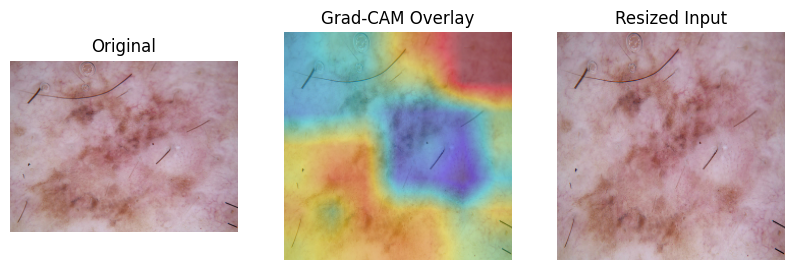

In [ ]:
# Cell 11: Grad-CAM helper functions and example (works with Keras models)
import tensorflow as tf
import cv2
import numpy as np
from tensorflow.keras.models import Model
from matplotlib import pyplot as plt

def find_last_conv_layer(model):
    # find last Conv2D layer name
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            return layer.name
    raise ValueError("No Conv2D layer found in the model.")

def make_gradcam_heatmap(img_array, model, last_conv_name, pred_index=None):
    grad_model = Model([model.inputs], [model.get_layer(last_conv_name).output, model.output])
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        loss = predictions[:, pred_index]
    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

def overlay_heatmap(img, heatmap, alpha=0.4, colormap=cv2.COLORMAP_JET):
    # img: uint8 RGB, heatmap: 2D normalized 0..1
    hmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    hmap = np.uint8(255 * hmap)
    color = cv2.applyColorMap(hmap, colormap)
    overlay = cv2.addWeighted(img, 1-alpha, color, alpha, 0)
    return overlay

# Example: pick one validation image and visualize grad-cam
sample_img_path = next(iter(glob.glob(os.path.join(DATASET_PATH, "**", "*.*"), recursive=True)), None)
if sample_img_path:
    img = cv2.imread(sample_img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    inp = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE)).astype(np.float32) / 255.0
    inp_batch = np.expand_dims(inp, axis=0)
    last_conv = find_last_conv_layer(clf_model)
    heatmap = make_gradcam_heatmap(inp_batch, clf_model, last_conv)
    vis = overlay_heatmap((inp*255).astype(np.uint8), heatmap)
    plt.figure(figsize=(10,4))
    plt.subplot(1,3,1); plt.imshow(img_rgb); plt.title("Original"); plt.axis('off')
    plt.subplot(1,3,2); plt.imshow(vis); plt.title("Grad-CAM Overlay"); plt.axis('off')
    plt.subplot(1,3,3); plt.imshow((inp*255).astype(np.uint8)); plt.title("Resized Input"); plt.axis('off')
else:
    print("No sample image found to show Grad-CAM example.")


Prepare YOLOv5 repo & requirements (Requirement 3 & 5)

In [ ]:
# Cell 12: Clone YOLOv5 repo (if not present) and install dependencies
YOLO_DIR = "/content/yolov5"
if not os.path.isdir(YOLO_DIR):
    print("Cloning YOLOv5 repo...")
    !git clone https://github.com/ultralytics/yolov5.git {YOLO_DIR}
else:
    print("YOLOv5 folder already exists; skipping clone.")

# change working directory to YOLOv5 repo (use separate cell to avoid comment-on-same-line issues)
%cd /content/yolov5

# install requirements quietly (may take 1-3 minutes)
!pip install -qr requirements.txt

# ensure Python path can import yolov5 (not strictly necessary for subprocess training)
import sys
sys.path.append(YOLO_DIR)
print("YOLOv5 ready at", YOLO_DIR, "Python path updated.")


Cloning YOLOv5 repo...
Cloning into '/content/yolov5'...
remote: Enumerating objects: 17778, done.
remote: Counting objects: 100% (154/154), done.
remote: Compressing objects: 100% (103/103), done.
remote: Total 17778 (delta 98), reused 51 (delta 51), pack-reused 17624 (from 4)
Receiving objects: 100% (17778/17778), 17.14 MiB | 16.34 MiB/s, done.
Resolving deltas: 100% (12077/12077), done.
/content/yolov5
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 31.5 MB/s eta 0:00:00
YOLOv5 ready at /content/yolov5 Python path updated.


Create YOLO dataset (images + labels) using pseudo bboxes if no masks

In [ ]:
# === Cell 13: Create YOLO dataset structure and pseudo bounding boxes ===
# This cell organizes images into YOLO format (images + labels) and
# generates bounding boxes automatically using Otsu thresholding.

import os
import glob
import random   #  needed for shuffling
import cv2
import numpy as np
from pathlib import Path

# Paths
YOLO_DATA = "/content/skin_cancer_yolo"
os.makedirs(YOLO_DATA, exist_ok=True)

# Create YOLO directory structure
for subset in ["train", "val", "test"]:
    os.makedirs(os.path.join(YOLO_DATA, "images", subset), exist_ok=True)
    os.makedirs(os.path.join(YOLO_DATA, "labels", subset), exist_ok=True)

# Make sure you already have 'classes' defined earlier
classes = ['Melanoma', 'BCC', 'SCC', 'Benign']

# Create train/val/test split (70/15/15)
all_files = []
for cls in classes:
    all_files += glob.glob(os.path.join(DATASET_PATH, cls, "*.*"))

random.shuffle(all_files)
n = len(all_files)
n_train = int(0.7 * n)
n_val = int(0.15 * n)
train_files = all_files[:n_train]
val_files = all_files[n_train:n_train + n_val]
test_files = all_files[n_train + n_val:]

# --- Function: create pseudo bounding box and save YOLO label ---
def create_yolo_label_and_copy(src, subset):
    img = cv2.imread(src)
    if img is None:
        return
    h, w = img.shape[:2]
    base = Path(src).stem

    # Destination paths
    dst_img = os.path.join(YOLO_DATA, "images", subset, base + ".jpg")
    dst_label = os.path.join(YOLO_DATA, "labels", subset, base + ".txt")

    # Save image in JPG format
    cv2.imwrite(dst_img, img)

    # --- Create pseudo-mask using Otsu threshold ---
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    _, th = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Clean noise
    kernel = np.ones((5, 5), np.uint8)
    th = cv2.morphologyEx(th, cv2.MORPH_OPEN, kernel)

    # Find contours and take the largest region
    contours, _ = cv2.findContours(th, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        c = max(contours, key=cv2.contourArea)
        x, y, w_box, h_box = cv2.boundingRect(c)
        x1, y1, x2, y2 = x, y, x + w_box, y + h_box
    else:
        # Fallback: full image box
        x1, y1, x2, y2 = 0, 0, w, h

    # Normalize to YOLO format
    xc = ((x1 + x2) / 2.0) / w
    yc = ((y1 + y2) / 2.0) / h
    bw = (x2 - x1) / w
    bh = (y2 - y1) / h

    # Save YOLO label: class_id x_center y_center width height
    with open(dst_label, "w") as f:
        f.write(f"0 {xc:.6f} {yc:.6f} {bw:.6f} {bh:.6f}\n")

# --- Apply to all subsets ---
for f in train_files:
    create_yolo_label_and_copy(f, "train")
for f in val_files:
    create_yolo_label_and_copy(f, "val")
for f in test_files:
    create_yolo_label_and_copy(f, "test")

# --- Summary ---
print("YOLO pseudo-dataset created successfully!\nCounts:")
for subset in ["train", "val", "test"]:
    imgs = len(glob.glob(os.path.join(YOLO_DATA, "images", subset, "*.jpg")))
    labs = len(glob.glob(os.path.join(YOLO_DATA, "labels", subset, "*.txt")))
    print(f" {subset}: {imgs} images, {labs} labels")


Create dataset.yaml for YOLO and show it

In [ ]:
# Cell 14: Write dataset.yaml required by YOLOv5
import yaml
dataset_yaml = {
    'train': os.path.join(YOLO_DATA, 'images', 'train'),
    'val':   os.path.join(YOLO_DATA, 'images', 'val'),
    'test':  os.path.join(YOLO_DATA, 'images', 'test'),
    'nc': 1,
    'names': ['lesion']
}
yaml_path = os.path.join(YOLO_DATA, "dataset.yaml")
with open(yaml_path, "w") as f:
    yaml.dump(dataset_yaml, f, sort_keys=False)
print("Wrote YOLO dataset.yaml at:", yaml_path)
!sed -n '1,120p' {yaml_path}


Train YOLOv5 (quick test training) — runs inside yolov5 dir

In [ ]:
# Cell 15: Train YOLOv5 using the dataset.yaml — WARNING: heavy compute
# Ensure you are in the yolov5 directory
%cd /content/yolov5

#  test quickly; increase --epochs for full training
!python train.py --img 320 --batch 4 --epochs 3 --data {yaml_path} --weights yolov5s.pt --project runs/train --name skin_yolo_test


/content/yolov5
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
wandb: WARNING ⚠️ wandb is deprecated and will be removed in a future release. See supported integrations at https://github.com/ultralytics/yolov5#integrations.
2026-01-12 06:54:58.564221: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768200898.945094   17998 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768200899.053595   17998 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for 

Run YOLO detection and compute IoU (validation)

In [ ]:
# Cell 16: After training, run detect.py on the test folder and compute IoU vs ground truth labels
%cd /content/yolov5

# find best weights produced by training
best_w = None
for p in sorted(glob.glob("runs/train/skin_yolo*/weights/best.pt"), reverse=True):
    best_w = p; break

if best_w is None:
    print("No best.pt found (training may not have completed). Check runs/train.")
else:
    print("Using weights:", best_w)
    # Run detection and save labels (predicted .txt in runs/detect/exp/labels)
    !python detect.py --weights {best_w} --img 640 --conf 0.25 --source {os.path.join(YOLO_DATA,'images','test')} --save-txt --project runs/detect --name skin_detect

    # compute IoU between predictions and ground-truth labels
    PRED_DIR = sorted(glob.glob("/content/yolov5/runs/detect/skin_detect*/labels"), reverse=True)[0]
    GT_DIR = os.path.join(YOLO_DATA, "labels", "test")
    IMG_DIR = os.path.join(YOLO_DATA, "images", "test")

    def yolo_to_bbox(line, w, h):
        parts = line.strip().split()
        if len(parts) < 5: return None
        _, xc, yc, bw, bh = map(float, parts)
        x1 = (xc - bw/2) * w; x2 = (xc + bw/2) * w
        y1 = (yc - bh/2) * h; y2 = (yc + bh/2) * h
        return [x1,y1,x2,y2]

    def iou(a,b):
        xA = max(a[0], b[0]); yA = max(a[1], b[1])
        xB = min(a[2], b[2]); yB = min(a[3], b[3])
        interW = max(0, xB-xA); interH = max(0, yB-yA)
        inter = interW*interH
        areaA = max(0, (a[2]-a[0]))*max(0, (a[3]-a[1]))
        areaB = max(0, (b[2]-b[0]))*max(0, (b[3]-b[1]))
        denom = areaA + areaB - inter + 1e-8
        return inter/denom if denom>0 else 0.0

    ious = []
    for gt in glob.glob(os.path.join(GT_DIR, "*.txt")):
        base = Path(gt).stem
        # find matching image dims
        img_file = None
        for ext in (".jpg",".png",".jpeg"):
            cand = os.path.join(IMG_DIR, base+ext)
            if os.path.exists(cand):
                img_file = cand; break
        if img_file is None:
            continue
        h,w = cv2.imread(img_file).shape[:2]
        gt_boxes = [yolo_to_bbox(l,w,h) for l in open(gt).read().strip().splitlines() if l.strip()]
        pred_file = os.path.join(PRED_DIR, base + ".txt")
        if not os.path.exists(pred_file):
            ious.append(0.0); continue
        pred_boxes = [yolo_to_bbox(l,w,h) for l in open(pred_file).read().strip().splitlines() if l.strip()]
        if not pred_boxes or not gt_boxes:
            ious.append(0.0); continue
        # IoU per predicted box = best IoU with any GT box
        per_pred = [max(iou(pb, gb) for gb in gt_boxes) for pb in pred_boxes]
        ious.append(np.mean(per_pred))
    print("Mean IoU over test set:", float(np.mean(ious)) if ious else "No IoU computed")


Simple Gradio GUI combining classifier + YOLO detection + Grad-CAM

In [ ]:
# Cell 17: Gradio app (loads Keras classifier and YOLO detector). Run after models created.
import gradio as gr
from PIL import Image
import torch

# load classifier if saved
if os.path.exists(MODEL_SAVE_PATH):
    from tensorflow.keras.models import load_model
    clf = load_model(MODEL_SAVE_PATH)
else:
    clf = None
    print("Classifier model not found at", MODEL_SAVE_PATH)

# load YOLO detector via torch.hub (ultralytics) if weights available
yolo_model = None
if best_w is not None and os.path.exists(best_w):
    yolo_model = torch.hub.load('ultralytics/yolov5', 'custom', path=best_w, force_reload=False)
else:
    print("YOLO weights not found; detector will not run.")

def predict(image):
    # image: PIL.Image
    arr = np.array(image.convert('RGB'))
    # Classification
    if clf is not None:
        img_resized = cv2.resize(arr, (IMG_SIZE, IMG_SIZE)).astype(np.float32)/255.0
        preds = clf.predict(np.expand_dims(img_resized,0))
        cls_idx = np.argmax(preds[0])
        label = {v:k for k,v in train_gen.class_indices.items()}[cls_idx]
    else:
        label = "No classifier"

    # Grad-CAM
    gradcam_img = None
    if clf is not None:
        inp = np.expand_dims(cv2.resize(arr, (IMG_SIZE, IMG_SIZE)).astype(np.float32)/255.0, 0)
        last_conv = None
        try:
            last_conv = find_last_conv_layer(clf)
            heat = make_gradcam_heatmap(inp, clf, last_conv)
            overlay = overlay_heatmap(arr, heat)
            gradcam_img = Image.fromarray(overlay)
        except Exception as e:
            gradcam_img = None

    # YOLO detection render
    detect_img = None
    if yolo_model is not None:
        results = yolo_model(arr)  # numpy array supported
        rendered = results.render()[0]  # rendered numpy
        detect_img = Image.fromarray(rendered)

    return label, detect_img, gradcam_img

iface = gr.Interface(fn=predict,
                     inputs=gr.Image(type="pil"),
                     outputs=[gr.Textbox(label="Classification"),
                              gr.Image(type="pil", label="YOLO Detection (rendered)"),
                              gr.Image(type="pil", label="Grad-CAM")],
                     title="Skin Lesion Classifier + Localizer")
print("Gradio interface ready. To run it in Colab, call iface.launch(share=True)")
# To start interactive app uncomment below:
# iface.launch(share=True)


In [ ]:
!find /content/yolov5/runs/train -name best.pt


In [ ]:
# === Cell 18: Evaluate YOLO model on validation set ===
%cd /content/yolov5

# Correct YOLO weights path
best_weights_path = "/content/yolov5/runs/train/skin_yolo_test/weights/best.pt"

# Run YOLO validation to evaluate performance on val set
!python val.py \
  --weights {best_weights_path} \
  --data {yaml_path} \
  --img 640 \
  --task val


In [ ]:
# === Cell 19: Visualize YOLO detection + Grad-CAM ===
import cv2
import matplotlib.pyplot as plt
from PIL import Image

# Pick a few validation images
sample_images = glob.glob("/content/skin_cancer_yolo/images/val/*.jpg")[:3]

for img_path in sample_images:
    img = Image.open(img_path).convert("RGB")
    label, detect_img, gradcam_img = predict(img)

    print(f" Prediction: {label}")
    plt.figure(figsize=(15,5))

    plt.subplot(1,3,1)
    plt.imshow(img)
    plt.title("Original")

    plt.subplot(1,3,2)
    if detect_img:
        plt.imshow(detect_img)
        plt.title("YOLO Detection")
    else:
        plt.text(0.5, 0.5, "No Detection", ha='center', va='center')

    plt.subplot(1,3,3)
    if gradcam_img:
        plt.imshow(gradcam_img)
        plt.title("Grad-CAM Visualization")
    else:
        plt.text(0.5, 0.5, "Grad-CAM not available", ha='center', va='center')

    plt.show()


In [ ]:
!zip -r /content/skin_models_backup.zip /content/yolov5/runs/train/skin_yolo_test/weights/best.pt {MODEL_SAVE_PATH}
from google.colab import files
files.download('/content/skin_models_backup.zip')


In [ ]:
# Paths to your models
MODEL_SAVE_PATH = "/content/mobilenet_best.h5"
YOLO_BEST_PATH = "/content/yolov5/runs/train/skin_yolo_test/weights/best.pt"

# Create a single zip with both models
!zip -r /content/skin_cancer_models.zip {MODEL_SAVE_PATH} {YOLO_BEST_PATH}

# Download the zip to your computer
from google.colab import files
files.download("/content/skin_cancer_models.zip")


In [ ]:
# === FINAL CELL: SKIN LESION CLASSIFIER + LOCALIZER (YOLO + MobileNet + Grad-CAM) ===
# ------------------------------------------------------------------------------------
# This single cell loads both models, processes an uploaded image,
# performs classification, object detection, and visualization with Grad-CAM.
# It also launches a Gradio app for easy user interaction.

# ==========================
#  Import Dependencies
# ==========================
import tensorflow as tf                     # Deep learning framework (for MobileNet classifier)
import numpy as np                           # Numerical operations
import cv2                                   # Image processing (OpenCV)
import gradio as gr                          # For creating the web interface
from tensorflow.keras.preprocessing import image  # Image preprocessing utilities
import torch                                 # For YOLOv5 object detection
from PIL import Image                        # For handling image inputs/outputs
from IPython.display import display          # Optional: to display outputs in Colab

# ==========================
#  Load Trained Classifier (MobileNet)
# ==========================
clf_path = "/content/mobilenet_best.h5"      # Path to your saved MobileNet model
clf = tf.keras.models.load_model(clf_path, compile=False)  # Load model without re-compilation
print(" MobileNet model loaded successfully!")
print("Model input shape:", clf.input_shape)
print("Model output shape:", clf.output_shape)

# ==========================
#  Load YOLOv5 Object Detection Model
# ==========================
yolo_weights = "/content/yolov5/runs/train/skin_yolo_test/weights/best.pt"  # Path to YOLO weights
yolo_model = torch.hub.load("ultralytics/yolov5", "custom", path=yolo_weights, force_reload=True)
print(" YOLOv5 model loaded successfully!")

# ==========================
#  Grad-CAM Function (Visualize Model Focus)
# ==========================
def get_gradcam_heatmap(img_array, model, layer_name=None):
    """
    Generates a Grad-CAM heatmap showing which parts of the image influenced
    the classifier’s decision the most.
    """
    try:
        # Automatically find the last convolutional layer if not given
        if layer_name is None:
            for layer in reversed(model.layers):
                if len(layer.output_shape) == 4:
                    layer_name = layer.name
                    break

        # Build a model that maps input → activations & predictions
        grad_model = tf.keras.models.Model(
            [model.inputs], [model.get_layer(layer_name).output, model.output]
        )

        # Compute gradients of top predicted class with respect to feature maps
        with tf.GradientTape() as tape:
            conv_outputs, predictions = grad_model(img_array)
            pred_index = tf.argmax(predictions[0])
            loss = predictions[:, pred_index]

        grads = tape.gradient(loss, conv_outputs)               # Gradient of loss wrt conv outputs
        pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))    # Channel-wise mean
        conv_outputs = conv_outputs[0]

        # Weight each channel by its importance and compute heatmap
        heatmap = tf.reduce_mean(tf.multiply(pooled_grads, conv_outputs), axis=-1)
        heatmap = np.maximum(heatmap, 0)                        # ReLU (remove negatives)
        if np.max(heatmap) != 0:
            heatmap /= np.max(heatmap)                          # Normalize to [0,1]
        return heatmap.numpy()

    except Exception as e:
        print(" Grad-CAM error:", e)
        return np.zeros((7, 7))  # Return blank map on failure

# ==========================
#  Preprocessing Function
# ==========================

def preprocess_image(img_path):
    # Read and convert image to RGB
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # --- Noise removal ---
    img = cv2.fastNlMeansDenoisingColored(img, None, 10, 10, 7, 21)

    # --- Contrast enhancement ---
    img = cv2.convertScaleAbs(img, alpha=1.3, beta=10)  # Adjust alpha/beta if needed

    # --- Resize and normalization ---
    img = cv2.resize(img, (224, 224))
    img_array = img / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    return img_array


# ==========================
#  Prediction + Visualization Pipeline
# ==========================
def predict(img):
    """
    Takes uploaded image → runs classification (MobileNet),
    detection (YOLO), and Grad-CAM visualization.
    """
    # Convert image (numpy) to PIL and save temporarily
    img_pil = Image.fromarray(img.astype('uint8'), 'RGB')
    temp_path = "/content/temp.jpg"
    img_pil.save(temp_path)

    # --- Step 1: Classification ---
    img_array = preprocess_image(temp_path)
    preds = clf.predict(img_array)
    class_names = ["Melanoma", "BCC", "SCC", "Benign"]
    pred_label = class_names[np.argmax(preds)]                # Pick top class
    confidence = np.max(preds) * 100
    classification = f"{pred_label} ({confidence:.2f}%)"      # Formatted prediction

    # --- Step 2: Grad-CAM Visualization ---
    heatmap = get_gradcam_heatmap(img_array, clf)             # Auto-selects best conv layer
    img_orig = cv2.imread(temp_path)
    heatmap = cv2.resize(heatmap, (img_orig.shape[1], img_orig.shape[0]))  # Resize heatmap
    heatmap = np.uint8(255 * heatmap)                         # Convert to RGB scale
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)    # Apply color map
    gradcam_output = cv2.addWeighted(img_orig, 0.6, heatmap, 0.4, 0)  # Overlay heatmap
    gradcam_output = cv2.cvtColor(gradcam_output, cv2.COLOR_BGR2RGB)  # Convert for display

    # --- Step 3: YOLO Object Detection ---
    results = yolo_model(temp_path)       # Run YOLOv5 inference
    results.render()                      # Draw bounding boxes
    yolo_img = results.ims[0]
    yolo_img = cv2.cvtColor(yolo_img, cv2.COLOR_BGR2RGB)      # Convert for display

    # Return all outputs
    return classification, yolo_img, gradcam_output

# ==========================
#  Gradio Web Interface
# ==========================
iface = gr.Interface(
    fn=predict,                                         # Function to call on input
    inputs=gr.Image(type="numpy", label="Upload Skin Image"),  # Input: image
    outputs=[
        gr.Textbox(label="Classification (MobileNet)"),        # Output 1: label + confidence
        gr.Image(label="YOLO Detection (Localized Lesion)"),   # Output 2: bounding boxes
        gr.Image(label="Grad-CAM (Model Focus)")               # Output 3: attention heatmap
    ],
    title="Skin Lesion Classifier + Localizer",         # App title
    description="Upload a skin lesion image to classify lesion type (MobileNet), "
                "localize affected region (YOLOv5), and visualize model focus using Grad-CAM."
)

# Launch app (share=True → public link)
iface.launch(share=True)
